# Task 3 · Cognitive load and the data-ink ratio

**Ali Afzal** · BSAI-7B-102 · Data Visualization · Week 2

First I build an overloaded chart, then strip it down one step at a time, then strip it too far. The aim is
to see which marks actually cost the reader effort.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# Paul Tol "bright" palette: stays distinct for colour-blind readers
RED, BLUE, GREY, INK = "#ee6677", "#4477aa", "#bbbbbb", "#333333"

plt.rcParams.update({
    "figure.dpi": 100,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})


def save(fig, name):
    fig.savefig(CHARTS / name, dpi=300, bbox_inches="tight")

import matplotlib.patheffects as pe

In [2]:
crash = pd.read_csv(DATA / "car_crashes.csv")
crash.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


`total` = drivers involved in fatal collisions **per billion miles** driven. That's the only column used for
the bar charts. The other columns are in different units: `speeding`, `alcohol` and the rest are rates
derived from percentages, and the `ins_*` columns are in dollars. Putting them on one axis would break a Week
1 rule. It isn't a cognitive-load problem.

## 1. The overloaded chart (on purpose)

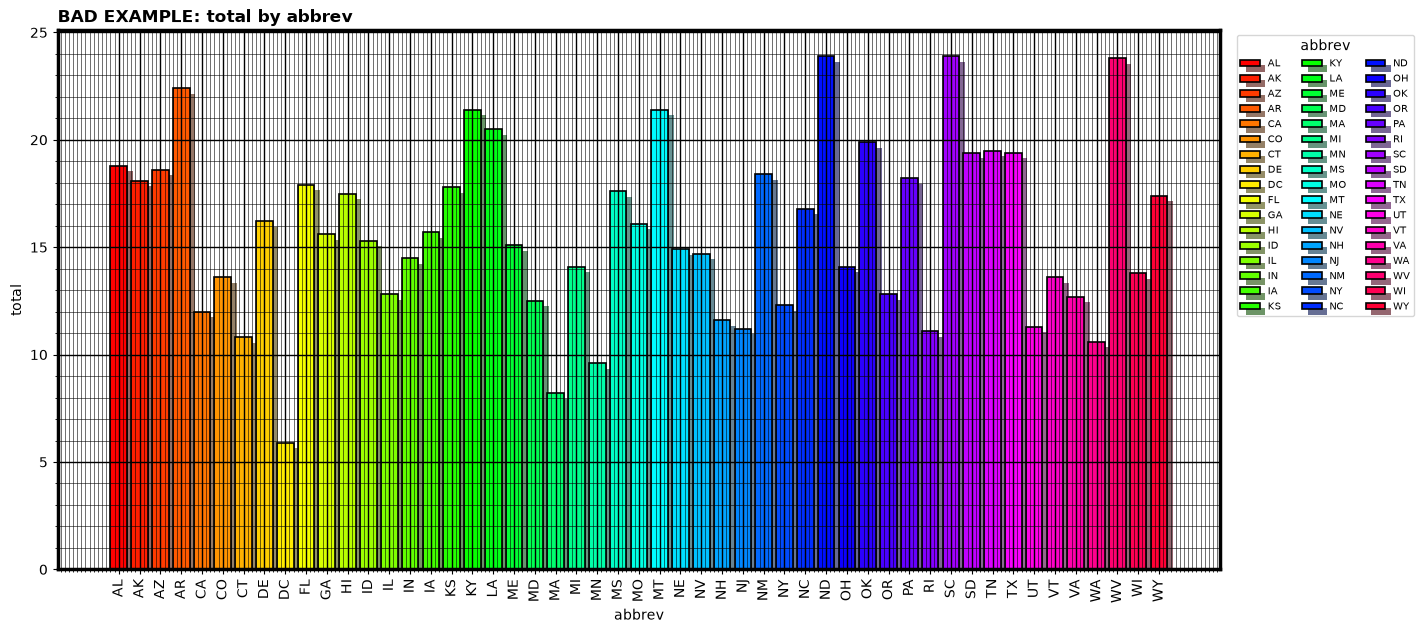

In [3]:
fig, ax = plt.subplots(figsize=(15, 7))
rainbow = plt.cm.hsv(np.linspace(0, 1, len(crash), endpoint=False))
bars = ax.bar(crash.abbrev, crash.total, color=rainbow, edgecolor="black", linewidth=1.2)
for bar in bars:
    bar.set_path_effects([pe.SimplePatchShadow(offset=(4, -4), alpha=0.6), pe.Normal()])

ax.legend(list(bars), crash.abbrev, title="abbrev", ncol=3, fontsize=7,
          loc="upper left", bbox_to_anchor=(1.01, 1))
ax.tick_params(axis="x", rotation=90)
ax.minorticks_on()
ax.grid(True, which="major", color="black", linewidth=1)
ax.grid(True, which="minor", color="black", linewidth=0.4)
for side in ax.spines.values():
    side.set_visible(True)
    side.set_linewidth(2.5)
ax.set_xlabel("abbrev")
ax.set_ylabel("total")
ax.set_title("BAD EXAMPLE: total by abbrev")
save(fig, "t3_1_bad_overloaded.png")

**What the eye does with it.** The rainbow grabs attention first. 51 hues all compete, so none of them
stands out. The eye then jumps to the legend to find out what the colours mean and finds only a second copy
of the x axis. A drop shadow sits beside every bar like a twin, and the black grid cuts each bar into dozens
of cells. After all that, the reader still has to scan 51 unsorted bars to answer the real question: which
states are worst?

## 2. Count the load

In [4]:
pd.set_option("display.max_colwidth", 120)

fig.canvas.draw()
lo, hi = ax.get_ylim()
y_major = sum(lo <= v <= hi for v in ax.yaxis.get_majorticklocs())
y_minor = sum(lo <= v <= hi for v in ax.yaxis.get_minorticklocs())
x_minor = len(ax.xaxis.get_minorticklocs())
n = len(crash)

audit = pd.DataFrame([
    ("Bars (height = value)",       n,           True,  "intrinsic",  "the 51 numbers; 51 of anything is a lot, and no design removes that"),
    ("51 different hues",           0,           False, "extraneous", "a property of the bars, not new marks; repeats the x label and implies a key"),
    ("Black bar outlines",          n,           False, "extraneous", "a border around a shape that's already visible"),
    ("Drop shadows",                n,           False, "extraneous", "fake depth; each shadow looks like a second, taller bar"),
    ("x tick labels, rotated 90°",  n,           False, "germane",    "needed to know which state is which; the rotation adds extraneous reading cost"),
    ("y tick labels",               y_major,     False, "germane",    "how a height becomes a number"),
    ("Horizontal major gridlines",  y_major,     False, "germane",    "help read values, but solid black makes them compete with the bars"),
    ("Vertical major gridlines",    n,           False, "extraneous", "each bar already marks its own x position"),
    ("Minor gridlines",             y_minor + x_minor, False, "extraneous", "precision nobody needs to rank states"),
    ("Box frame",                   4,           False, "extraneous", "encloses an area the axes already define"),
    ("Legend swatches + labels",    2 * n,       False, "extraneous", "a second copy of the x axis, read by colour matching"),
    ("Legend frame + title",        2,           False, "extraneous", "a box around the duplicate"),
    ("Title 'total by abbrev'",     1,           False, "extraneous", "names the axes and states no finding, so the reader must find the point"),
    ("Axis labels 'total', 'abbrev'", 2,         False, "extraneous", "column names with no units"),
], columns=["element", "marks", "encodes_a_number", "load", "why"])

data_marks = audit.loc[audit.encodes_a_number, "marks"].sum()
total_marks = audit.marks.sum()
print(f"data-ink ratio ~ {data_marks} data marks / {total_marks} total marks = {data_marks / total_marks:.2f}")
audit

data-ink ratio ~ 51 data marks / 628 total marks = 0.08


,element,marks,encodes_a_number,load,why
0,Bars (height = value),51,True,intrinsic,"the 51 numbers; 51 of anything is a lot, and no design removes that"
1,51 different hues,0,False,extraneous,"a property of the bars, not new marks; repeats the x label and implies a key"
2,Black bar outlines,51,False,extraneous,a border around a shape that's already visible
3,Drop shadows,51,False,extraneous,"fake depth; each shadow looks like a second, taller bar"
4,"x tick labels, rotated 90°",51,False,germane,needed to know which state is which; the rotation adds extraneous reading cost
5,y tick labels,6,False,germane,how a height becomes a number
6,Horizontal major gridlines,6,False,germane,"help read values, but solid black makes them compete with the bars"
7,Vertical major gridlines,51,False,extraneous,each bar already marks its own x position
8,Minor gridlines,250,False,extraneous,precision nobody needs to rank states
9,Box frame,4,False,extraneous,encloses an area the axes already define


About **one mark in twelve** encodes a number. Counting marks treats a tiny gridline the same as a big bar, so
measured by area of ink the ratio would be a little higher. It would still be low.

The only intrinsic load is the 51 values themselves. Everything that adds to it is extraneous: the 51 hues,
the shadows and the legend. The germane parts are the labels and the y-scale, which help the reader compare,
but here they're drawn in a way that makes the comparison harder.

## 3. Strip it down, one step at a time

I follow the suggested order, with one change: the shadows and bar outlines go out in step 2 along with the
frame. All three are decoration around the data, so they belong in the same step.

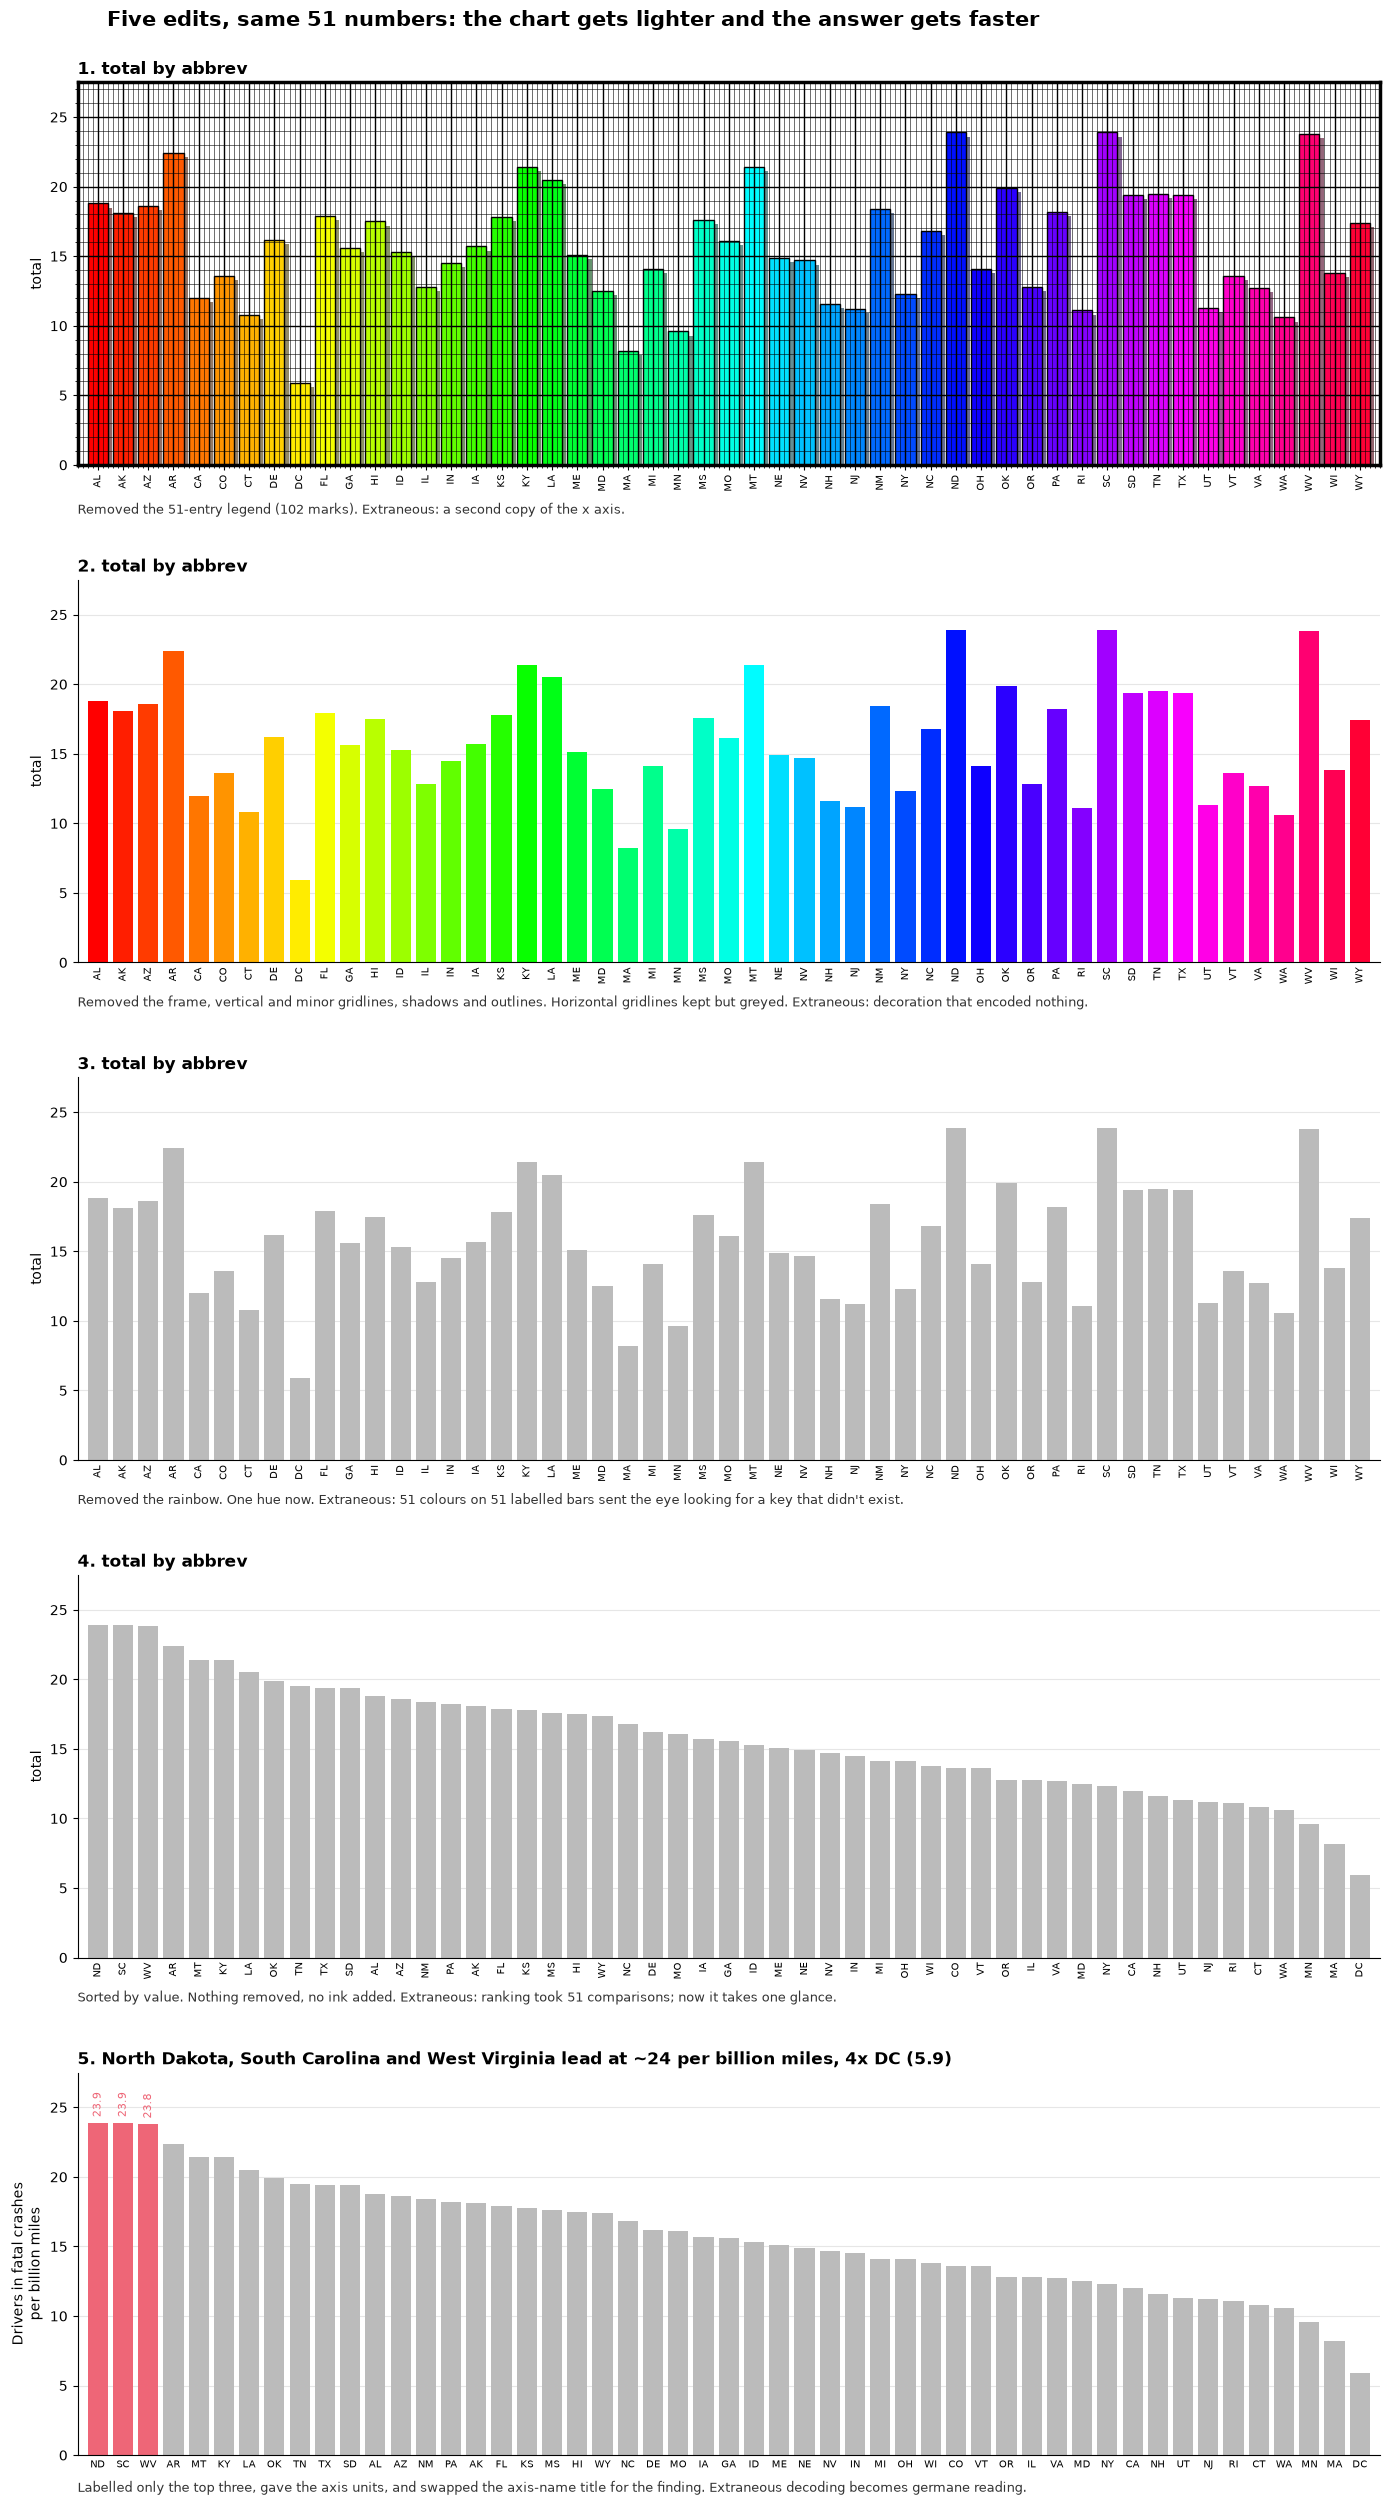

In [5]:
TOP3 = crash.nlargest(3, "total").abbrev.tolist()

CAPTIONS = [
    "Removed the 51-entry legend (102 marks). Extraneous: a second copy of the x axis.",
    "Removed the frame, vertical and minor gridlines, shadows and outlines. Horizontal gridlines kept but "
    "greyed. Extraneous: decoration that encoded nothing.",
    "Removed the rainbow. One hue now. Extraneous: 51 colours on 51 labelled bars sent the eye looking "
    "for a key that didn't exist.",
    "Sorted by value. Nothing removed, no ink added. Extraneous: ranking took 51 comparisons; now it "
    "takes one glance.",
    "Labelled only the top three, gave the axis units, and swapped the axis-name title for the finding. "
    "Extraneous decoding becomes germane reading.",
]


def stage(ax, step):
    d = crash.sort_values("total", ascending=False) if step >= 4 else crash
    if step >= 5:
        colour = [RED if s in TOP3 else GREY for s in d.abbrev]
    elif step >= 3:
        colour = GREY
    else:
        colour = rainbow
    bars = ax.bar(d.abbrev, d.total, color=colour,
                  edgecolor="black" if step < 2 else "none", linewidth=1)

    if step < 2:
        for bar in bars:
            bar.set_path_effects([pe.SimplePatchShadow(offset=(3, -3), alpha=0.6), pe.Normal()])
        ax.minorticks_on()
        ax.grid(True, which="major", color="black", linewidth=1)
        ax.grid(True, which="minor", color="black", linewidth=0.4)
        for side in ax.spines.values():
            side.set_visible(True)
            side.set_linewidth(2.5)
    else:
        ax.grid(axis="y", color="#e6e6e6", linewidth=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(axis="x", length=0)

    if step >= 5:
        for bar, state in zip(bars, d.abbrev):
            if state in TOP3:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                        f"{bar.get_height():.1f}", ha="center", va="bottom", rotation=90,
                        fontsize=8, color=RED)
        ax.tick_params(axis="x", rotation=0, labelsize=7)
        ax.set_ylabel("Drivers in fatal crashes\nper billion miles")
        lowest = crash.nsmallest(1, "total").iloc[0]
        ax.set_title(f"{step}. North Dakota, South Carolina and West Virginia lead at ~24 per billion miles, "
                     f"4x {lowest.abbrev} ({lowest.total})")
    else:
        ax.tick_params(axis="x", rotation=90, labelsize=7)
        ax.set_ylabel("total")
        ax.set_title(f"{step}. total by abbrev")
    ax.set_xlim(-0.8, len(d) - 0.2)
    ax.set_ylim(0, 27.5)
    ax.set_xlabel(CAPTIONS[step - 1], loc="left", fontsize=9.5, color=INK, labelpad=8)


fig, axes = plt.subplots(5, 1, figsize=(14, 25))
for step, ax in enumerate(axes, 1):
    stage(ax, step)
fig.suptitle("Five edits, same 51 numbers: the chart gets lighter and the answer gets faster",
             x=0.08, y=1.0, ha="left", fontsize=15, fontweight="bold")
fig.tight_layout(h_pad=3)
save(fig, "t3_3_five_step_strip.png")

**Reading down the panels.** Panels 1 and 2 take away noise. The chart stops buzzing, but the question is
still hard to answer. In panel 3 the eye stops doing pointless work: with one grey hue, nothing pretends to
carry meaning. Panel 4 makes the ranking visible. The worst states sit on the left and the safest on the
right, and half of all states fall between about 13 and 19. Panel 5 adds back three numbers and one colour,
and the chart finally answers the question. North Dakota, South Carolina and West Virginia, at about 24, are
four times DC's 5.9.

**Step 4 is the most useful edit, and it adds no ink at all.** Sorting doesn't change the data-ink ratio, but
it turns "which states are worst?" from 51 comparisons into a glance at the left edge. Data-ink counts marks,
not effort, and this edit only saves effort.

## 4. Respect the 4 ± 1 limit

**Chunking chosen: the four US Census regions.** Four chunks fit working memory exactly.

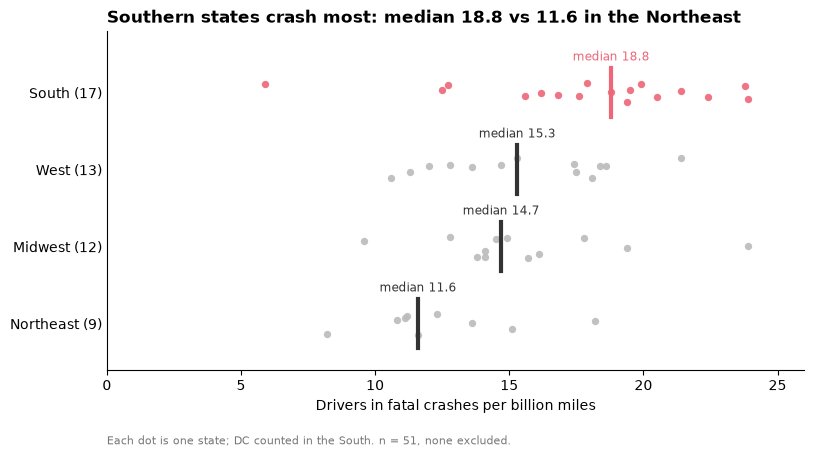

In [6]:
REGION = {
    "Northeast": "CT ME MA NH RI VT NJ NY PA",
    "Midwest": "IL IN MI OH WI IA KS MN MO NE ND SD",
    "South": "DE FL GA MD NC SC VA DC WV AL KY MS TN AR LA OK TX",
    "West": "AZ CO ID MT NV NM UT WY AK CA HI OR WA",
}
crash["region"] = crash.abbrev.map({s: r for r, states in REGION.items() for s in states.split()})
assert crash.region.notna().all()

medians = crash.groupby("region").total.median().sort_values()
worst = medians.index[-1]
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(9, 4.4))
for i, region in enumerate(medians.index):
    d = crash[crash.region == region]
    hot = region == worst
    ax.scatter(d.total, i + rng.uniform(-0.15, 0.15, len(d)), s=28, linewidths=0,
               color=RED if hot else GREY, alpha=0.9)
    ax.plot([medians[region]] * 2, [i - 0.32, i + 0.32], color=RED if hot else INK, lw=3)
    ax.text(medians[region], i + 0.38, f"median {medians[region]:.1f}", ha="center", va="bottom",
            fontsize=8.5, color=RED if hot else INK)

ax.set_yticks(range(len(medians)),
              [f"{r} ({(crash.region == r).sum()})" for r in medians.index])
ax.tick_params(axis="y", length=0)
ax.set_ylim(-0.6, len(medians) - 0.2)
ax.set_xlim(0, 26)
ax.set_xlabel("Drivers in fatal crashes per billion miles")
ax.set_title(f"Southern states crash most: median {medians[worst]:.1f} vs "
             f"{medians.iloc[0]:.1f} in the {medians.index[0]}")
ax.annotate("Each dot is one state; DC counted in the South. n = 51, none excluded.",
            xy=(0, -0.22), xycoords="axes fraction", fontsize=8, color="#777777")
save(fig, "t3_4_chunked_regions.png")

In [7]:
for region, d in crash.groupby("region"):
    top = d.nlargest(1, "total").iloc[0]
    print(f"{region:<10} highest state: {top.abbrev} ({top.total})")

Midwest    highest state: ND (23.9)
Northeast  highest state: PA (18.2)
South      highest state: SC (23.9)
West       highest state: MT (21.4)


**What it shows.** The South's median, 18.8, is 7 points above the Northeast's 11.6. The West (15.3) and
Midwest (14.7) sit between them. The regions overlap a lot, though. The South also holds DC, the lowest dot
on the chart at 5.9.

**Position on a common scale** carries the number, so dots are compared along one x axis. **Proximity** does
the grouping, since each region's states sit on their own row. The one red row is the finding.

**What this chunking costs.** It hides which state is which. North Dakota, tied for the highest rate in the
country, disappears into a Midwest row whose median is ordinary. Montana does the same in the West. The chart
answers "which region?" well and "which state?" not at all. Every chunking trades detail for something you
can hold in your head, and this is the detail it gives up.

## 5. Over-strip it

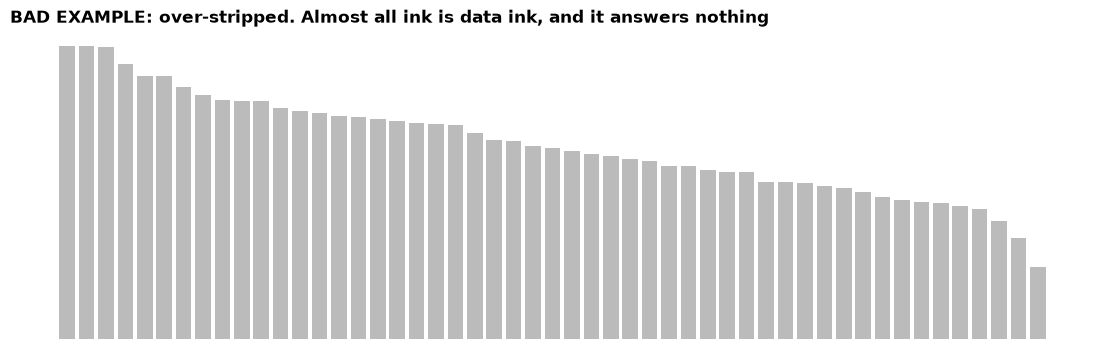

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
d = crash.sort_values("total", ascending=False)
ax.bar(range(len(d)), d.total, color=GREY)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[["left", "bottom"]].set_visible(False)
ax.set_title("BAD EXAMPLE: over-stripped. Almost all ink is data ink, and it answers nothing")
save(fig, "t3_5_bad_overstripped.png")

Nearly every mark here is a bar, so the data-ink ratio is close to **1.0**, the "best" score in the notebook.
It's also useless. You can't tell which bar is which state, what a bar's height means, what the units are or
whether the tallest bar is high at all. The reader has nothing to compare against.

**Stopping rule:** *Keep deleting until the next deletion would make the reader ask you a question, then
stop.*

## The question: when adding ink lowers load (`tips.csv`)

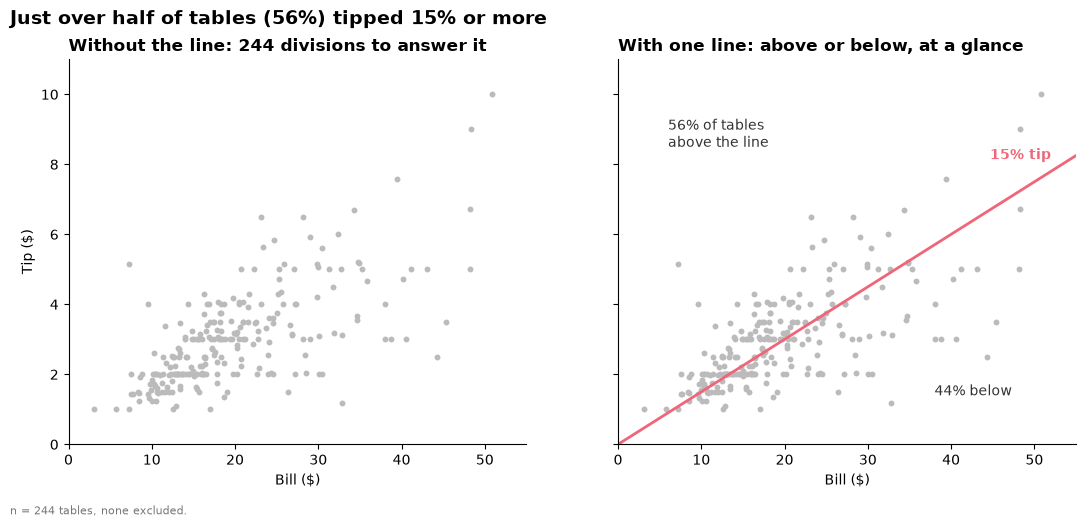

In [9]:
tips = pd.read_csv(DATA / "tips.csv")
tips["tip_rate"] = tips.tip / tips.total_bill
share = (tips.tip_rate >= 0.15).mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax in axes:
    ax.scatter(tips.total_bill, tips.tip, s=18, color=GREY, linewidths=0)
    ax.set_xlabel("Bill ($)")
    ax.set_xlim(0, 55)
    ax.set_ylim(0, 11)
axes[0].set_ylabel("Tip ($)")
axes[0].set_title("Without the line: 244 divisions to answer it")

x = np.array([0, 55])
axes[1].plot(x, 0.15 * x, color=RED, lw=2)
axes[1].text(52, 0.15 * 52 + 0.35, "15% tip", color=RED, ha="right", fontweight="bold")
axes[1].text(6, 8.5, f"{share:.0%} of tables\nabove the line", color=INK)
axes[1].text(38, 1.4, f"{1 - share:.0%} below", color=INK)
axes[1].set_title("With one line: above or below, at a glance")

fig.suptitle(f"Just over half of tables ({share:.0%}) tipped 15% or more",
             x=0.08, ha="left", fontsize=14, fontweight="bold")
fig.text(0.08, -0.03, "n = 244 tables, none excluded.", fontsize=8, color="#777777")
save(fig, "t3_q_reference_line.png")

The red line is **non-data ink**. Tufte's ratio says it lowers the score. But without it, "did this table
tip 15%?" means dividing tip by bill for every dot, which is 244 calculations in working memory. With it,
each dot is simply above or below a line. That's a **position** judgement, and the eye makes it
preattentively for all 244 dots at once. One line of ink saves 244 calculations.

That's why "maximise data-ink" is a **heuristic, not a rule**. It counts ink, and ink is only a stand-in for
the real cost, which is the reader's effort. Most of the time less ink means less effort. When a reference
line, a direct label or an annotation does a calculation the reader would otherwise do in their head,
adding ink lowers the load.